In [7]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os##
##for dirname, _, filenames in os.walk('/kaggle/input'):
   ## for filename in filenames:
     ##   print(os.path.join(dirname, filename))##

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None



In [9]:
train = pd.read_csv('/kaggle/input/tamil-hwcr/train.csv')
train.head()

,ID,Class Label
0,1.bmp,2
1,2.bmp,3
2,3.bmp,4
3,4.bmp,5
4,5.bmp,6


In [10]:
test = pd.read_csv('/kaggle/input/tamil-hwcr/test.csv')
test.head()

,ID
0,1.bmp
1,2.bmp
2,3.bmp
3,4.bmp
4,5.bmp


In [11]:
combined = pd.concat([train,test])
combined.head()

,ID,Class Label
0,1.bmp,2.0
1,2.bmp,3.0
2,3.bmp,4.0
3,4.bmp,5.0
4,5.bmp,6.0


In [6]:
combined.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 90950 entries, 0 to 28079
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           90950 non-null  object 
 1   Class Label  62870 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.1+ MB


In [7]:
combined.dtypes

ID              object
Class Label    float64
dtype: object

In [8]:
combined.isnull().sum()/len(combined)*100

ID              0.000000
Class Label    30.874107
dtype: float64

In [9]:
combined.shape

(90950, 2)

In [10]:

combined.describe().T

,count,mean,std,min,25%,50%,75%,max
Class Label,62870.0,77.601861,44.977283,0.0,39.0,78.0,116.0,155.0


In [11]:
combined.skew()

/tmp/ipykernel_32/3158812268.py:1: FutureWarning: The default value of numeric_only in DataFrame.skew is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.skew()


Class Label   -0.003643
dtype: float64

In [12]:
combined.kurt()

/tmp/ipykernel_32/292944781.py:1: FutureWarning: The default value of numeric_only in DataFrame.kurt is deprecated. In a future version, it will default to False. In addition, specifying 'numeric_only=None' is deprecated. Select only valid columns or specify the value of numeric_only to silence this warning.
  combined.kurt()


Class Label   -1.195599
dtype: float64

<Axes: >

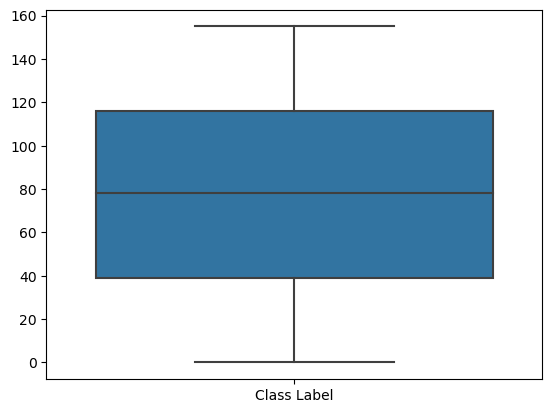

In [13]:
sns.boxplot(combined)

<Axes: >

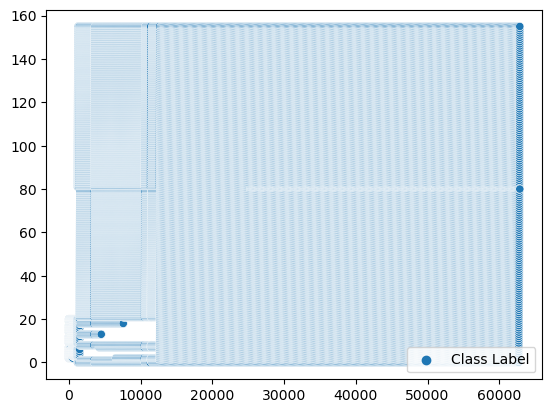

In [14]:
sns.scatterplot(combined)

<Axes: >

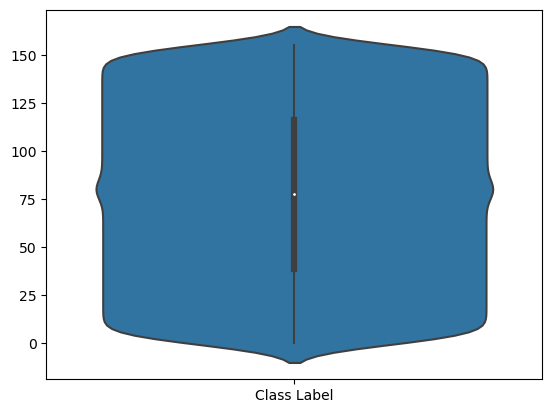

In [15]:
sns.violinplot(combined)

/tmp/ipykernel_32/1658940522.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(combined.corr(),annot=True)


<Axes: >

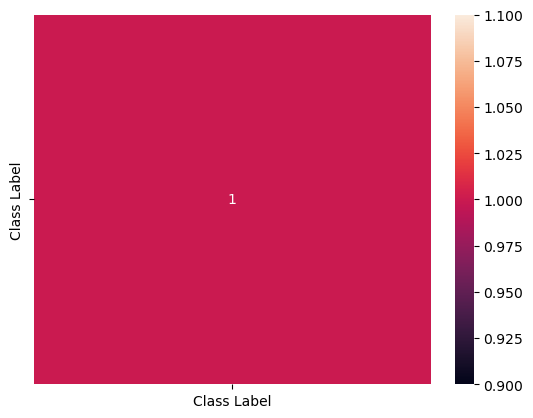

In [16]:
sns.heatmap(combined.corr(),annot=True)

<Axes: ylabel='Density'>

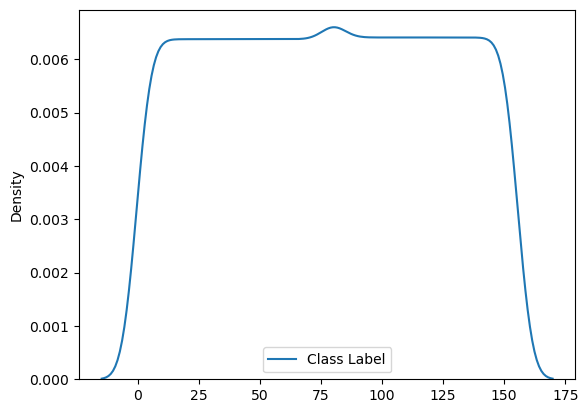

In [17]:
sns.kdeplot(combined)

<Axes: >

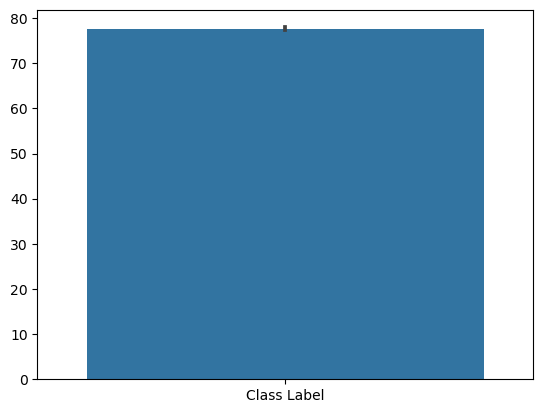

In [18]:
sns.barplot(combined)

<Axes: >

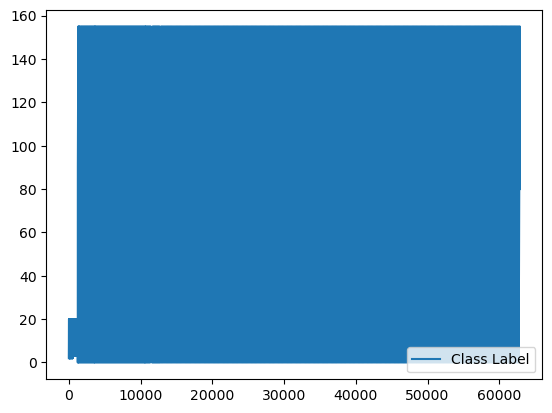

In [19]:
sns.lineplot(combined)

In [20]:
Q1 = combined.quantile(0.25)
Q2 = combined.quantile(0.5)
Q3 = combined.quantile(0.75)
IQR=Q3-Q1
print(IQR)

Class Label    77.0
dtype: float64


/tmp/ipykernel_32/2240195514.py:1: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q1 = combined.quantile(0.25)
/tmp/ipykernel_32/2240195514.py:2: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q2 = combined.quantile(0.5)
/tmp/ipykernel_32/2240195514.py:3: FutureWarning: The default value of numeric_only in DataFrame.quantile is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  Q3 = combined.quantile(0.75)


In [21]:
UL = Q3+(1.5*IQR)
LL = Q1-(1.5*IQR)

In [22]:
combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]

/tmp/ipykernel_32/1567334620.py:1: FutureWarning: Automatic reindexing on DataFrame vs Series comparisons is deprecated and will raise ValueError in a future version. Do `left, right = left.align(right, axis=1, copy=False)` before e.g. `left == right`
  combined_new = combined[~((combined<UL)|(combined>LL)).any(axis=1)]


In [23]:
combined_new.shape

(28080, 2)

In [47]:
cat_cols = combined.select_dtypes(include='object')

In [48]:
for i in cat_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

ID
1.bmp        2
18718.bmp    2
18729.bmp    2
18728.bmp    2
18727.bmp    2
            ..
39672.bmp    1
39671.bmp    1
39670.bmp    1
39669.bmp    1
62870.bmp    1
Name: ID, Length: 62870, dtype: int64
__________________________________________________
Class Label
nan    90950
Name: Class Label, dtype: int64
__________________________________________________


In [49]:
num_cols = combined.select_dtypes(include='number')

In [50]:
for i in num_cols:
    print(i)
    print(combined[i].value_counts())
    print('_'*50)

In [28]:
combined['ID']=combined['ID'].map({"Good":2,"standrad":1,'Poor':0})

<function matplotlib.pyplot.show(close=None, block=None)>

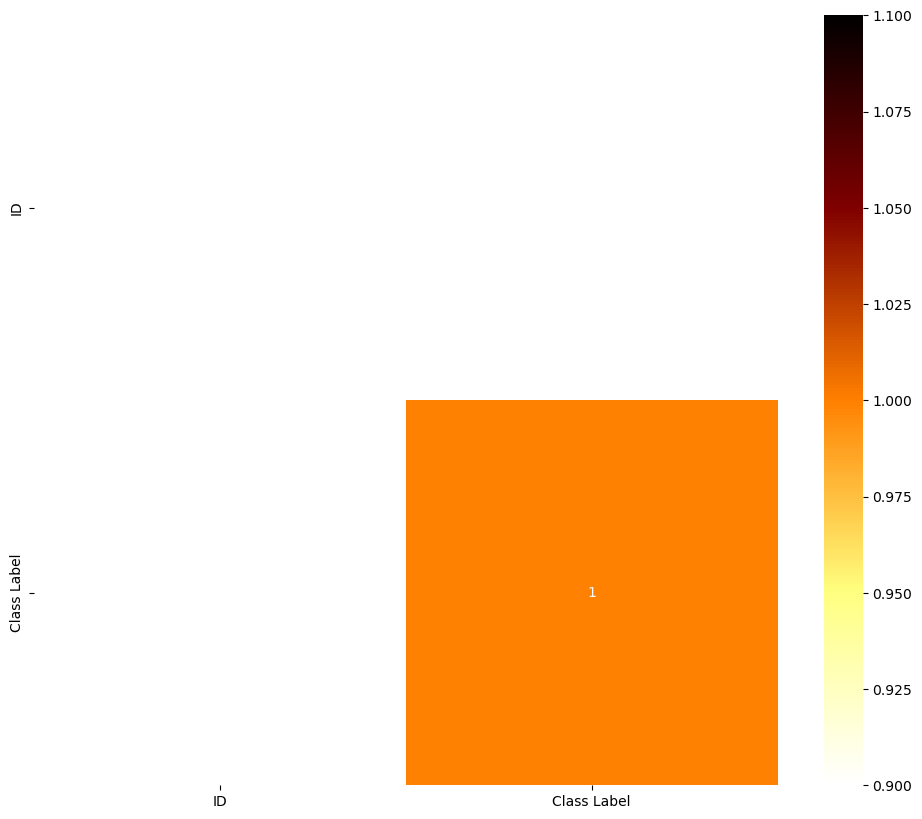

In [29]:
plt.figure(figsize=(12,10))
sns.heatmap(combined.corr(),annot=True,cmap='afmhot_r')
plt.show

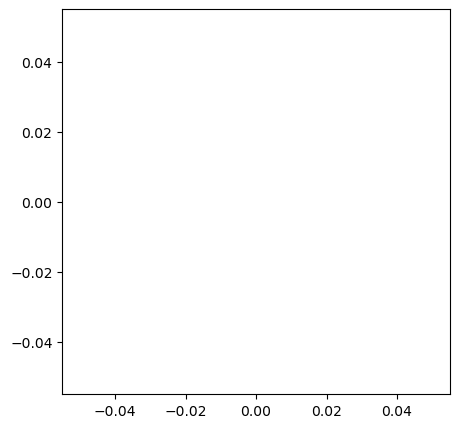

In [30]:
plt.figure(figsize=(5,5))
x=1
for i in cat_cols:
    sns.histplot(data=combined,x=i,kde=True)
    print('\n')
    plt.show()
    

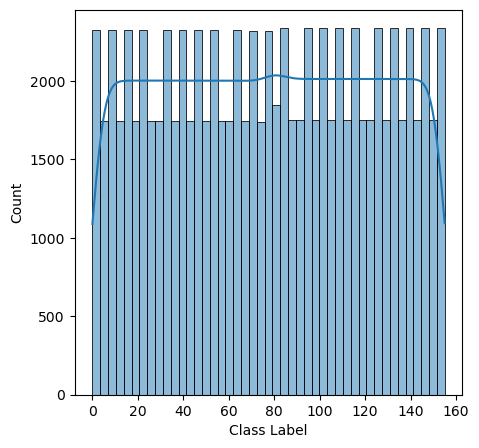

In [31]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=combined,kde=True,x=i)
    print('\n')
    plt.show()

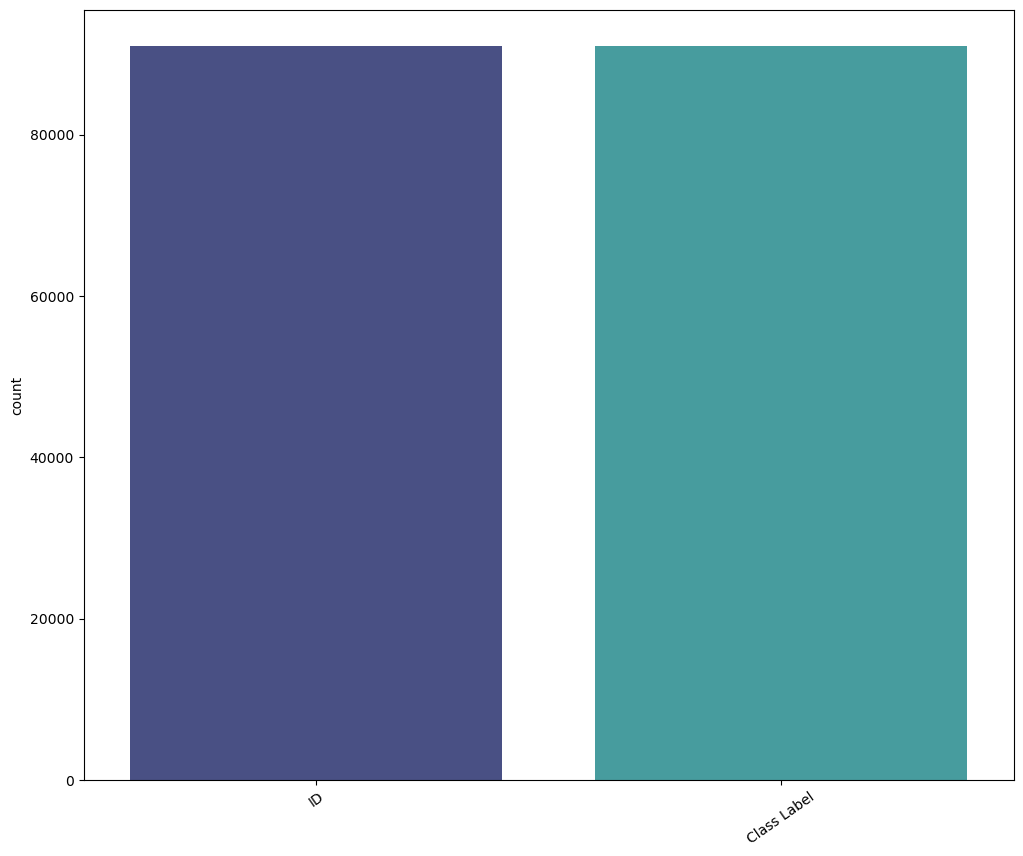

In [32]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,palette='mako');
plt.xticks(rotation=35);

/opt/conda/lib/python3.10/site-packages/seaborn/algorithms.py:98: RuntimeWarning: Mean of empty slice
  boot_dist.append(f(*sample, **func_kwargs))
/opt/conda/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1559: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a,


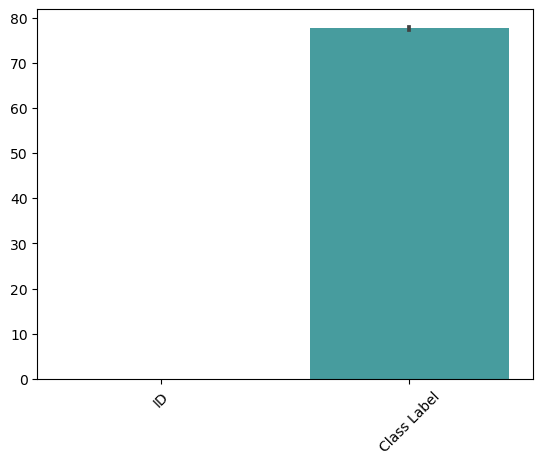

In [33]:
sns.barplot(data=combined,palette='mako');
plt.xticks(rotation=45);

(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140., 160., 180.]),
 [Text(-20.0, 0, '−20'),
  Text(0.0, 0, '0'),
  Text(20.0, 0, '20'),
  Text(40.0, 0, '40'),
  Text(60.0, 0, '60'),
  Text(80.0, 0, '80'),
  Text(100.0, 0, '100'),
  Text(120.0, 0, '120'),
  Text(140.0, 0, '140'),
  Text(160.0, 0, '160'),
  Text(180.0, 0, '180')])

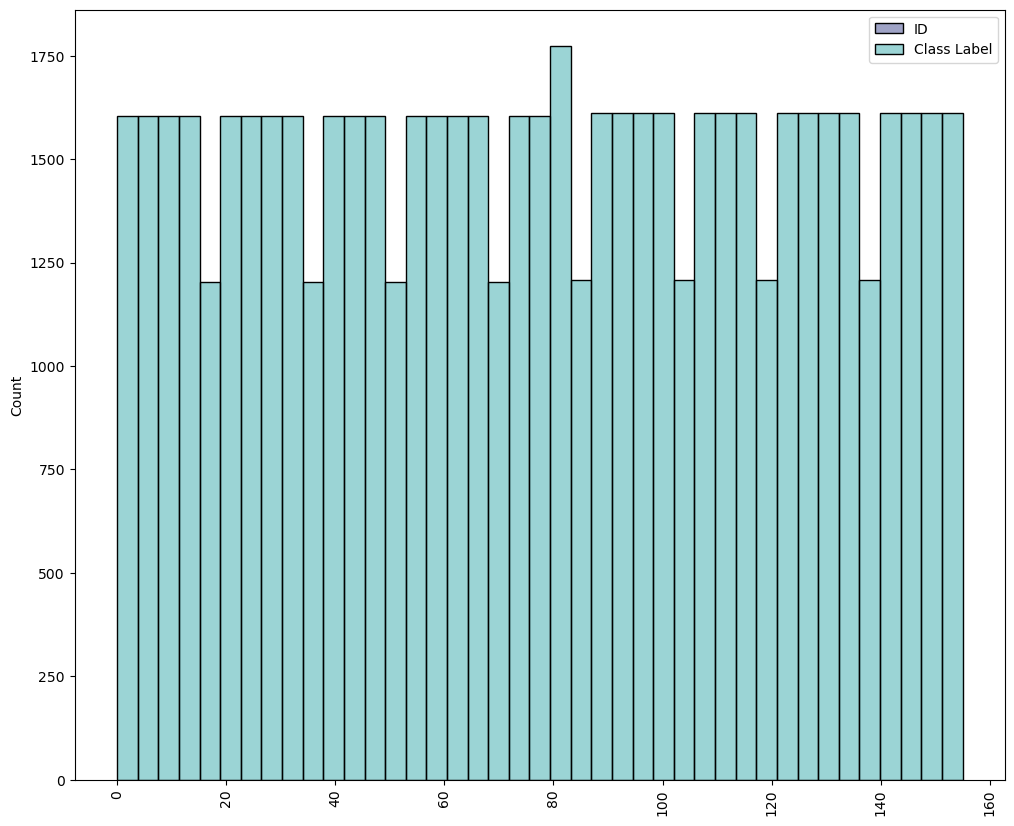

In [34]:
plt.figure(figsize=(12,10))
sns.histplot(data=combined,palette='mako')
plt.xticks(rotation=90)

In [35]:
combined['ID'].value_counts()

Series([], Name: ID, dtype: int64)

In [36]:
combined['ID'].unique()

array([nan])

In [37]:
combined['ID'].append

<bound method Series.append of 0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
28075   NaN
28076   NaN
28077   NaN
28078   NaN
28079   NaN
Name: ID, Length: 90950, dtype: float64>

/opt/conda/lib/python3.10/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


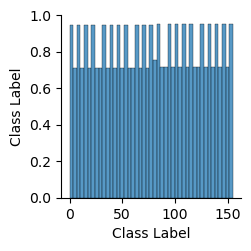

In [13]:
sns.pairplot(combined)

In [15]:
combined['ID']=combined['ID'].str.split('_').str[0]

In [17]:
combined['ID'].isnull().sum()

0

In [18]:
combined['ID'].nunique()

62870

In [19]:
combined.head()

,ID,Class Label
0,1.bmp,2.0
1,2.bmp,3.0
2,3.bmp,4.0
3,4.bmp,5.0
4,5.bmp,6.0


In [20]:
# Replacing weird value
combined = combined.applymap(lambda x: x if x is np.NaN or not isinstance(x,str)else str(x).strip('_,"')
                            ).replace(['','nan','!@9#%8','#F%$D@*&8'],np.NaN)


In [21]:
combined.head()

,ID,Class Label
0,1.bmp,2.0
1,2.bmp,3.0
2,3.bmp,4.0
3,4.bmp,5.0
4,5.bmp,6.0


In [22]:
combined['Class Label'].value_counts().head(9).index[1:]

Float64Index([121.0, 130.0, 129.0, 128.0, 127.0, 126.0, 125.0, 124.0], dtype='float64')

In [25]:
# Rebuild type of Class Label columns
for i in combined['ID'].value_counts().head(9).index[1:]:
    combined[i]=combined['ID'].str.contains(i)

In [27]:
combined.head(84)

,ID,Class Label,18718.bmp,18729.bmp,18728.bmp,18727.bmp,18726.bmp,18725.bmp,18724.bmp,18723.bmp
0,1.bmp,2.0,False,False,False,False,False,False,False,False
1,2.bmp,3.0,False,False,False,False,False,False,False,False
2,3.bmp,4.0,False,False,False,False,False,False,False,False
3,4.bmp,5.0,False,False,False,False,False,False,False,False
4,5.bmp,6.0,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...
79,80.bmp,20.0,False,False,False,False,False,False,False,False
80,81.bmp,2.0,False,False,False,False,False,False,False,False
81,82.bmp,3.0,False,False,False,False,False,False,False,False
82,83.bmp,4.0,False,False,False,False,False,False,False,False


In [28]:
combined['Class Label']=combined['Class Label'].astype(float)

In [29]:
extreme=combined[(combined['Class Label']>85) |(combined['Class Label']<0)].index

In [30]:
for i in extreme:
    combined.loc[i,'Class Label']=np.nan

In [31]:
combined.head()

,ID,Class Label,18718.bmp,18729.bmp,18728.bmp,18727.bmp,18726.bmp,18725.bmp,18724.bmp,18723.bmp
0,1.bmp,2.0,False,False,False,False,False,False,False,False
1,2.bmp,3.0,False,False,False,False,False,False,False,False
2,3.bmp,4.0,False,False,False,False,False,False,False,False
3,4.bmp,5.0,False,False,False,False,False,False,False,False
4,5.bmp,6.0,False,False,False,False,False,False,False,False


In [34]:
mapping = combined.groupby('Class Label').mean().to_dict()

/tmp/ipykernel_33/2705764401.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  mapping = combined.groupby('Class Label').mean().to_dict()


In [35]:
combined['Class Label']=combined['Class Label'].map(mapping)

In [41]:
combined['Class Label']=combined['Class Label'].astype(str)

In [42]:
combined.head()

,ID,Class Label,18718.bmp,18729.bmp,18728.bmp,18727.bmp,18726.bmp,18725.bmp,18724.bmp,18723.bmp
0,1.bmp,nan,False,False,False,False,False,False,False,False
1,2.bmp,nan,False,False,False,False,False,False,False,False
2,3.bmp,nan,False,False,False,False,False,False,False,False
3,4.bmp,nan,False,False,False,False,False,False,False,False
4,5.bmp,nan,False,False,False,False,False,False,False,False


In [43]:
combined.isnull().sum()

ID             0
Class Label    0
18718.bmp      0
18729.bmp      0
18728.bmp      0
18727.bmp      0
18726.bmp      0
18725.bmp      0
18724.bmp      0
18723.bmp      0
dtype: int64

In [44]:
# Replacing nm value in Class Label
combined['Class Label']=combined['Class Label'].replace({'NM':'Other'})

In [45]:
combined['Class Label'].value_counts()

nan    90950
Name: Class Label, dtype: int64

In [51]:
cat_cols

,ID,Class Label
0,1.bmp,nan
1,2.bmp,nan
2,3.bmp,nan
3,4.bmp,nan
4,5.bmp,nan
...,...,...
28075,28076.bmp,nan
28076,28077.bmp,nan
28077,28078.bmp,nan
28078,28079.bmp,nan


In [53]:
plt.figure(figsize=(10,5))
iterator=1
for i in num_cols:
    plt.subplot(4,2,iterator)
    sns.countplot(combined[i])
    iterator+=1
plt.tight_layout()

<Figure size 1000x500 with 0 Axes>

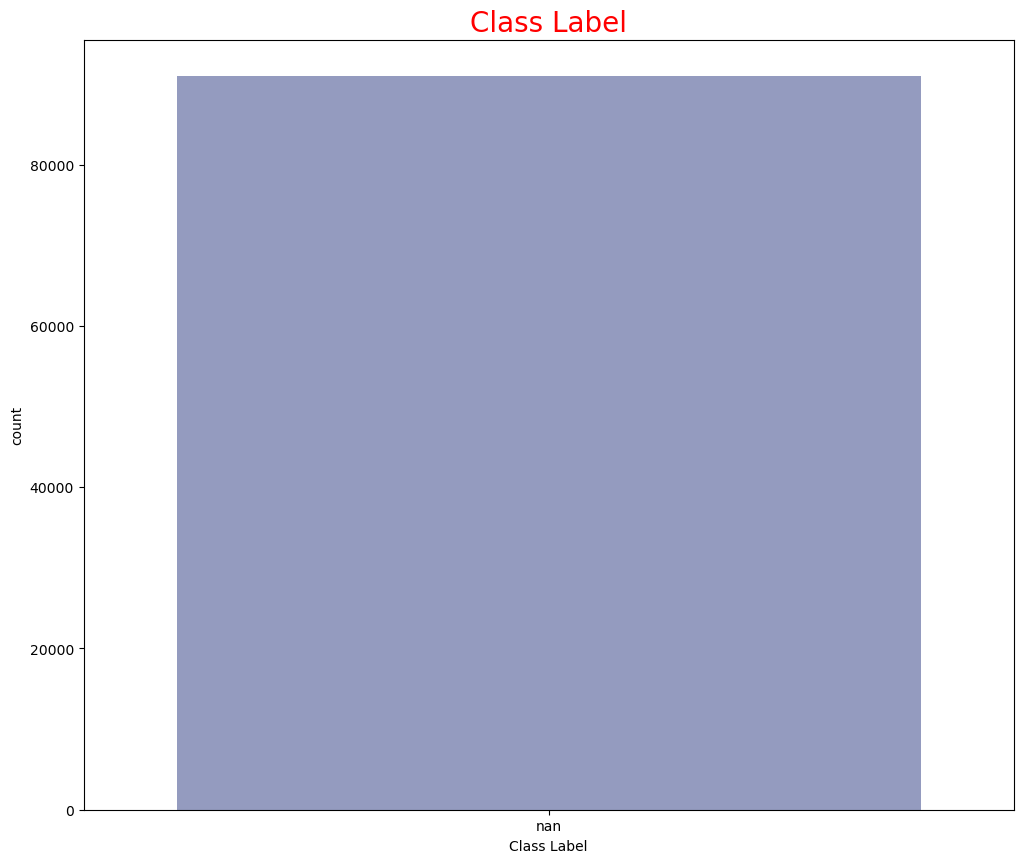

In [56]:
plt.figure(figsize=(12,10))
sns.countplot(data=combined,x='Class Label',palette='BuPu_r')
plt.title('Class Label',size=20,color='Red')
plt.show()


In [57]:
train.shape

(62870, 2)

In [58]:
new_train=combined.iloc[0:train.shape[0],:]

In [59]:
new_test=combined.iloc[train.shape[0]:,:]

In [60]:
train.shape,new_train.shape,test.shape,new_test.shape

((62870, 2), (62870, 10), (28080, 1), (28080, 10))

In [63]:
num_cols = combined.select_dtypes(include='number')
cat_cols = combined.select_dtypes(include='object')

In [64]:
sig_num=[]
for i in num_cols:
    zero=new_train.loc[new_train['ID']==0,i]
    one=new_train.loc[new_train['ID']==1,i]
    two=new_train.loc[new_train['ID']==2,i]
    teststat,pval=stats.f_oneway(zero,one,two)
    if pval<0.05:
        sig_num.append(i)
        print(i)

In [65]:
sig_cat=[]
for i in num_cols:
    tb1=pd.crosstab(nwew_train[i],new_train['ID'])
    tstat,pval,dof,freq=stats.chi2_contingency(tb1)
    if pval<0.05:
        sig_cat.append(i)
        print(i)

In [66]:
train_new = new_train.loc[:,sig_cat+sig_num]

In [68]:
test_new=new_test.loc[:,sig_cat+sig_num]

In [ ]:
# Checking for multicollinearity


In [69]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [70]:
train_new

""
0
1
2
3
4
...
62865
62866
62867
62868


In [72]:
test_new

""
0
1
2
3
4
...
28075
28076
28077
28078


In [80]:
# Scaling the cols
scaling=[]


In [81]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [82]:
for i in scaling:
    train_new.loc[:,i]=scaler.fit_transform(pd.DataFrame(train_new.loc[:,i]))
    test_new.loc[:,i]=scaler.transform(pd.DataFrame(test_new.loc[:,i]))

In [83]:
train_new

""
0
1
2
3
4
...
62865
62866
62867
62868


In [84]:
test_new

""
0
1
2
3
4
...
28075
28076
28077
28078
